In [ ]:
# =========================
# 1. Import libraries
# =========================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from copy import deepcopy

# =========================
# 2. Configuration
# =========================

# Select device: GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image size for resizing
image_size = 128

# Batch size for training
batch_size = 32

# Path to dataset
data_path = "C:/Users/nadia/2/machine_learning/lab5/cell_images"

# Path to save CAM (Class Activation Maps) results
save_cam_path = "C:/Users/nadia/2/machine_learning/lab5/cam_results"

# Create directory if it doesn't exist
os.makedirs(save_cam_path, exist_ok=True)

# =========================
# 3. Custom Dataset
# =========================

# Custom dataset for loading malaria cell images
class MalariaDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        # Return dataset size
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image and convert to RGB
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        # Apply transformations if provided
        if self.transform:
            image = self.transform(image)

        return image, label, self.image_paths[idx]

# =========================
# 4. Data preprocessing
# =========================

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])

# Define paths to class folders
infected_dir = os.path.join(data_path, "Parasitized")
uninfected_dir = os.path.join(data_path, "Uninfected")

# Load image paths for both classes
infected_paths = [os.path.join(infected_dir, f) for f in os.listdir(infected_dir) if f.endswith(".png")]
uninfected_paths = [os.path.join(uninfected_dir, f) for f in os.listdir(uninfected_dir) if f.endswith(".png")]

# Combine data and create labels (1 = infected, 0 = uninfected)
all_paths = infected_paths + uninfected_paths
all_labels = [1]*len(infected_paths) + [0]*len(uninfected_paths)

# Split dataset into train and test sets
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.1, random_state=42, stratify=all_labels
)

# Create dataset objects
train_dataset = MalariaDataset(train_paths, train_labels, transform)
test_dataset = MalariaDataset(test_paths, test_labels, transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1)

# =========================
# 5. CNN Model Definition
# =========================

# Simple Convolutional Neural Network for image classification
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()

        # Feature extractor (convolutional layers)
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )

        # Fully connected layer for classification
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        # Extract feature maps
        feats = self.features(x)

        # Flatten features
        out = feats.view(feats.size(0), -1)

        # Classification layer
        out = self.classifier(out)

        return out, feats

# Initialize model
model = SimpleCNN().to(device)

# =========================
# 6. Training setup
# =========================

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Loss function (for classification)
criterion = nn.CrossEntropyLoss()

# Training parameters
num_epochs = 30
patience = 2  # Early stopping patience

best_val_loss = float('inf')
best_model_state = None
counter = 0

# =========================
# 7. Training loop
# =========================

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    # Training phase
    for images, labels, _ in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs, _ = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation phase
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for images, labels, _ in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs, _ = model(images)
            loss = criterion(outputs, labels)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(test_loader)

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Early stopping logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best model weights
model.load_state_dict(best_model_state)

Epoch 1, Train Loss: 0.6479, Val Loss: 0.5658
Epoch 2, Train Loss: 0.4260, Val Loss: 0.3752
Epoch 3, Train Loss: 0.3564, Val Loss: 0.3341
Epoch 4, Train Loss: 0.3409, Val Loss: 0.2800
Epoch 5, Train Loss: 0.2940, Val Loss: 0.2458
Epoch 6, Train Loss: 0.2210, Val Loss: 0.2132
Epoch 7, Train Loss: 0.2164, Val Loss: 0.1778
Epoch 8, Train Loss: 0.2022, Val Loss: 0.2050
Epoch 9, Train Loss: 0.1965, Val Loss: 0.1673
Epoch 10, Train Loss: 0.1889, Val Loss: 0.1754
Epoch 11, Train Loss: 0.1859, Val Loss: 0.1877
Early stopping at epoch 11


<All keys matched successfully>

Image 0 — Predicted class: 1, Actual label: 1


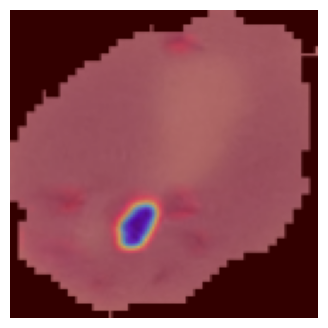

Image 1 — Predicted class: 1, Actual label: 1


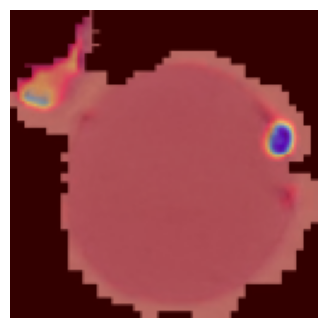

Image 2 — Predicted class: 0, Actual label: 0


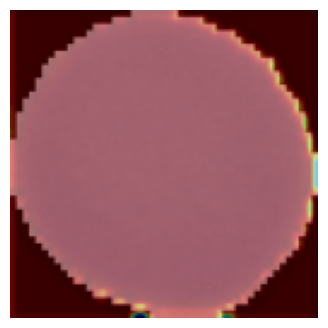

Image 3 — Predicted class: 0, Actual label: 0


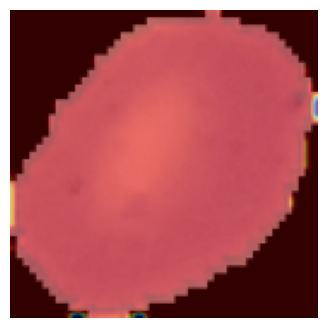

Image 4 — Predicted class: 1, Actual label: 1


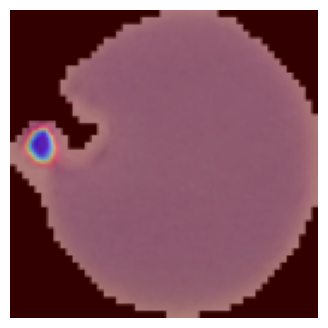

Image 5 — Predicted class: 1, Actual label: 1


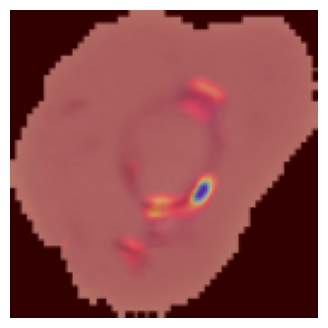

Image 6 — Predicted class: 0, Actual label: 0


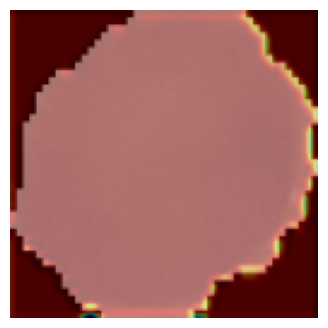

Image 7 — Predicted class: 0, Actual label: 0


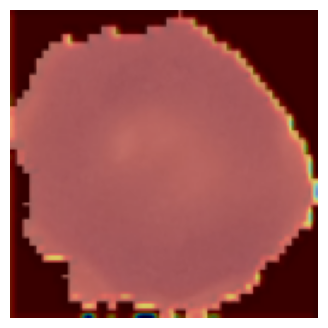

Image 8 — Predicted class: 1, Actual label: 1


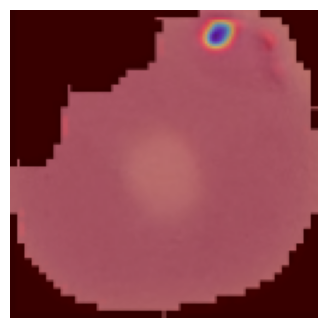

Image 9 — Predicted class: 1, Actual label: 0


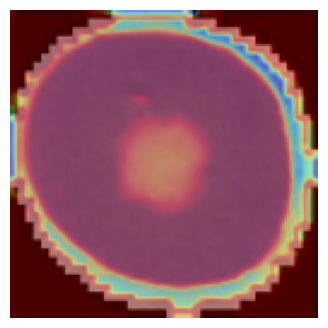

In [ ]:
# =========================
# 8. Build CAM using Grad-CAM
# =========================

# Variables for storing gradients and activations from the target layer
gradients = None
activations = None

# Hook function to save gradients during backpropagation
def save_gradient(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

# Hook function to save activations during the forward pass
def save_activation(module, input, output):
    global activations
    activations = output

# Select target convolutional layer for Grad-CAM
target_layer = model.features[4]
target_layer.register_forward_hook(save_activation)
target_layer.register_backward_hook(save_gradient)

# Generate Grad-CAM heatmap for a given input image and target class
def generate_gradcam(input_image, target_class):
    model.zero_grad()
    output, _ = model(input_image)
    class_score = output[0, target_class]
    class_score.backward()

    # Compute channel-wise importance weights from gradients
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

    # Weight feature maps by the corresponding gradients
    for i in range(activations.shape[1]):
        activations[:, i, :, :] *= pooled_gradients[i]

    # Aggregate weighted feature maps into a single CAM
    cam = activations.squeeze().sum(0).detach().cpu()
    cam = F.relu(cam)

    # Normalize CAM to the range [0, 1]
    cam -= cam.min()
    cam /= cam.max()

    return cam.numpy()

# Overlay CAM heatmap on the original image
def show_cam_on_image(img_tensor, cam):
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img * 255).astype(np.uint8)

    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    overlay = heatmap * 0.4 + img / 255 * 0.6
    overlay = np.uint8(overlay * 255)

    plt.figure(figsize=(4, 4))
    plt.imshow(overlay)
    plt.axis('off')
    plt.show()

# =========================
# 9. Generate and visualize Grad-CAM for test images
# =========================

model.eval()

for i, (images, labels, paths) in enumerate(test_loader):
    images = images.to(device)

    # Predict class for the current image
    with torch.no_grad():
        outputs, _ = model(images)
        pred_class = outputs.argmax(dim=1).item()

    # Generate Grad-CAM for the predicted class
    cam = generate_gradcam(images, pred_class)

    print(f"Image {i} — Predicted class: {pred_class}, Actual label: {labels.item()}")

    # Display image with CAM overlay
    show_cam_on_image(images[0].cpu(), cam)

    # Stop after 10 examples
    if i == 9:
        break

Image 0 — Predicted class: 1, Actual label: 1


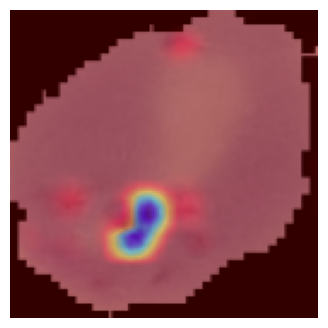

Image 1 — Predicted class: 1, Actual label: 1


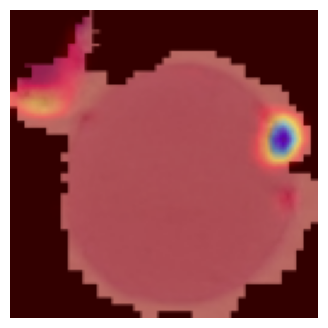

Image 2 — Predicted class: 0, Actual label: 0


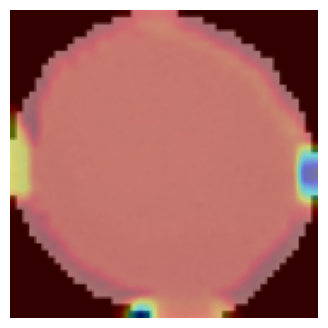

Image 3 — Predicted class: 0, Actual label: 0


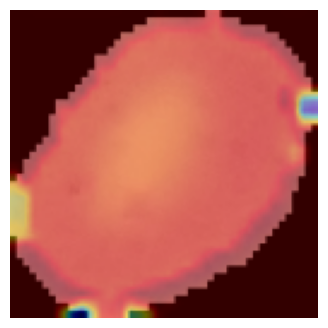

Image 4 — Predicted class: 1, Actual label: 1


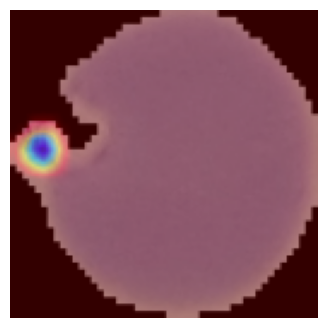

Image 5 — Predicted class: 1, Actual label: 1


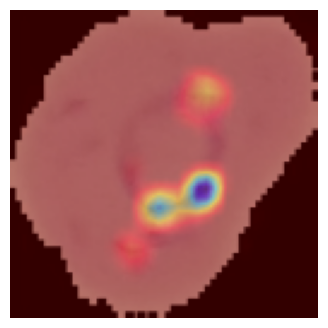

Image 6 — Predicted class: 0, Actual label: 0


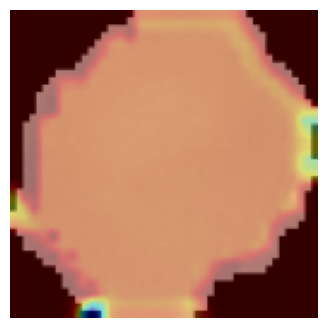

Image 7 — Predicted class: 0, Actual label: 0


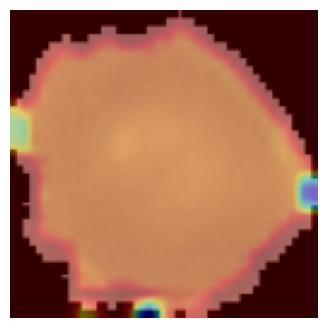

Image 8 — Predicted class: 1, Actual label: 1


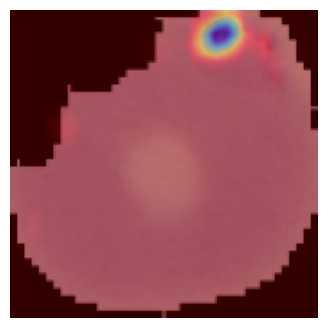

Image 9 — Predicted class: 1, Actual label: 0


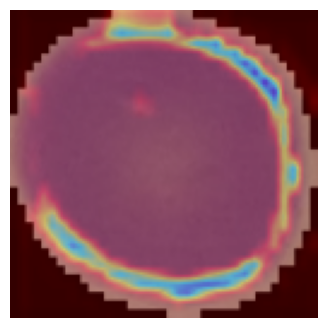

In [ ]:
# =========================
# 10. Build CAM (Class Activation Map)
# =========================

# Generate CAM using feature maps and classifier weights
def generate_cam(input_image, predicted_class):
    with torch.no_grad():
        # Extract feature maps from the convolutional layers (excluding the last pooling layer)
        activ_map = model.features[:-1](input_image)

        # Get weights of the fully connected layer
        fc_weights = model.classifier.weight.data

        # Select weights corresponding to the predicted class
        class_weights = fc_weights[predicted_class]

        # Initialize empty CAM
        cam = torch.zeros(activ_map.shape[2:], dtype=torch.float32).to(device)

        # Compute weighted sum of feature maps
        for i in range(len(class_weights)):
            cam += class_weights[i] * activ_map[0, i, :, :]

        # Apply ReLU to keep only positive contributions
        cam = F.relu(cam)

        # Normalize CAM to the range [0, 1]
        cam -= cam.min()
        cam /= cam.max()

        return cam.cpu().numpy()

# =========================
# 11. Generate and visualize CAM for test images
# =========================

model.eval()

for i, (images, labels, paths) in enumerate(test_loader):
    images = images.to(device)

    # Predict class for the input image
    with torch.no_grad():
        outputs, _ = model(images)
        pred_class = outputs.argmax(dim=1).item()

    # Generate CAM for the predicted class
    cam = generate_cam(images, pred_class)

    print(f"Image {i} — Predicted class: {pred_class}, Actual label: {labels.item()}")

    # Visualize CAM overlay on the image
    show_cam_on_image(images[0].cpu(), cam)

    # Stop after 10 samples
    if i == 9:
        break